# VLM Counterfactual Consistency — Demo

This notebook runs through the full pipeline on three GQA examples:
1. **Generate** counterfactual question families
2. **Run inference** with LLaVA-1.5 (or a fine-tuned LoRA checkpoint)
3. **Score** consistency across each family
4. **Visualize** the results

Images are loaded from `Data/images/`. Model weights are downloaded from HuggingFace on first run (`llava-hf/llava-1.5-7b-hf`).

## 0. Setup

In [1]:
import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path('.').resolve() / 'src'))

from counterfactual.generate_counterfactuals import generate_counterfactual_family
from evaluation.consistency_score import score_family

IMAGES_DIR = Path('Data/images')
LORA_CHECKPOINT = 'results/checkpoints/lora_llava/epoch_2'
# Set to None to evaluate the base model without any LoRA adapter:
# LORA_CHECKPOINT = None

print('Imports OK')

Imports OK


## 1. Demo Examples

Three GQA samples covering different question types (`yes/no` and `spatial`).

In [2]:
DEMO_EXAMPLES = [
    {
        'question_id': '15485398',
        'image_id': '2404539',
        'question': 'Is the grilled food to the right of the long meat?',
        'answer': 'yes',
        'question_type': 'yes/no',
    },
    {
        'question_id': '19117060',
        'image_id': '1160153',
        'question': 'Is the umbrella on the right of the image?',
        'answer': 'no',
        'question_type': 'yes/no',
    },
    {
        'question_id': '16269983',
        'image_id': '2407148',
        'question': 'What is the person to the left of the cat sitting on?',
        'answer': 'bed',
        'question_type': 'spatial',
    },
]

print(f'{len(DEMO_EXAMPLES)} examples loaded')

3 examples loaded


### Preview demo images

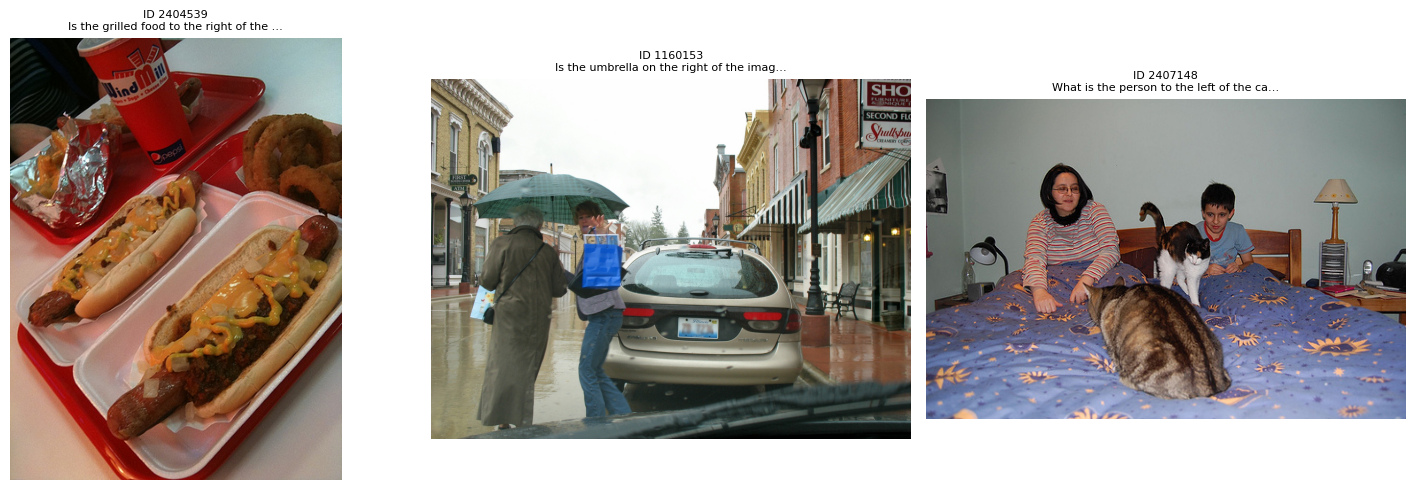

In [3]:
fig, axes = plt.subplots(1, len(DEMO_EXAMPLES), figsize=(15, 5))
for ax, example in zip(axes, DEMO_EXAMPLES):
    img_path = IMAGES_DIR / f"{example['image_id']}.jpg"
    ax.imshow(Image.open(img_path))
    ax.set_title(f"ID {example['image_id']}\n{example['question'][:40]}…", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Generate Counterfactual Families

In [4]:
families = [generate_counterfactual_family(ex) for ex in DEMO_EXAMPLES]

for family in families:
    family['counterfactuals'] = [
        cf for cf in family['counterfactuals']
        if cf['intervention_type'] != 'negation'
    ]

for family in families:
    orig = family['original']
    print(f"\nQ: {orig['question']}  (GT: {orig['answer']}, type: {orig['question_type']})")
    for cf in family['counterfactuals']:
        print(f"  [{cf['intervention_type']:22s}] {cf['counterfactual_question']}")
        print(f"  {'':24s}  expected={cf['expected_answer']}, relation={cf['logical_relation']}")


Q: Is the grilled food to the right of the long meat?  (GT: yes, type: yes/no)
  [entailment            ] Is the entity or relation mentioned in the question present in the image?
                            expected=yes, relation=entails
  [spatial_perturbation  ] Is the grilled food to the left of the long meat?
                            expected=unknown, relation=spatial_change

Q: Is the umbrella on the right of the image?  (GT: no, type: yes/no)
  [entailment            ] Is the entity or relation mentioned in the question present in the image?
                            expected=yes, relation=entails
  [spatial_perturbation  ] Is the umbrella on the left of the image?
                            expected=unknown, relation=spatial_change

Q: What is the person to the left of the cat sitting on?  (GT: bed, type: spatial)
  [entailment            ] Are the referenced objects visible in the image?
                            expected=yes, relation=entails
  [spatial_perturbation 

## 3. Load LLaVA-1.5 and Run Inference

Auto-detects available VRAM and drops to 4-bit quantization (QLoRA) on GPUs with less than 12 GB, so this runs fine on an 8 GB card without any config changes.

In [5]:
from models.run_llava import LlavaRunner

runner = LlavaRunner(lora_checkpoint=LORA_CHECKPOINT)
print('Model ready')

/home/he-man/miniconda3/envs/vlm-cf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights:   0%|          | 2/686 [00:00<02:33,  4.46it/s]/home/he-man/miniconda3/envs/vlm-cf/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 686/686 [00:14<00:00, 47.65it/s] 
/home/he-man/miniconda3/envs/vlm-cf/lib/python3.11/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Model ready


In [6]:
for family in families:
    img_path = str(IMAGES_DIR / f"{family['image_id']}.jpg")

    family['original']['model_prediction'] = runner.answer_question(
        img_path, family['original']['question']
    )

    for cf in family['counterfactuals']:
        cf['model_prediction'] = runner.answer_question(
            img_path, cf['counterfactual_question']
        )

    orig = family['original']
    print(f"Q: {orig['question']}")
    print(f"   GT={orig['answer']}  pred={orig['model_prediction']}")
    for cf in family['counterfactuals']:
        print(f"   [{cf['intervention_type']:22s}] pred={cf['model_prediction']}")
    print()

/home/he-man/miniconda3/envs/vlm-cf/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: Is the grilled food to the right of the long meat?
   GT=yes  pred=Yes, the grilled food is a hot dog, and it is to the right of the long meat.
   [entailment            ] pred=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes
   [spatial_perturbation  ] pred=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes

Q: Is the umbrella on the right of the image?
   GT=no  pred=No, the umbrella is on the left side of the image.
   [entailment            ] pred=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes
   [spatial_perturbation  ] pred=Yes, the umbrella is on the left side of the image.

Q: What is the person to the left of the cat sitting on?
   GT=bed  pred=Bedspreads and blankets on th

## 4. Score Consistency

In [10]:
results = [score_family(family) for family in families]

for res in results:
    marker = '[Correct]' if res['original_correct'] else '[Wrong]'
    print(f"{marker} Q: {res['original_question']}")
    print(f"  GT={res['original_answer']}  pred={res['original_model_prediction']}")
    print(f"  Consistency: {res['family_consistency_score']:.2f}  "
          f"({res['passed_count']}/{res['total_counterfactuals']} passed)")
    for item in res['details']:
        status = 'PASS' if item['passed'] else 'FAIL'
        print(f"  [{status}] {item['intervention_type']:22s}  "
              f"expected={item['expected_answer']}  got={item['model_prediction']}")
    print()

[Correct] Q: Is the grilled food to the right of the long meat?
  GT=yes  pred=Yes, the grilled food is a hot dog, and it is to the right of the long meat.
  Consistency: 0.50  (1/2 passed)
  [PASS] entailment              expected=yes  got=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes
  [FAIL] spatial_perturbation    expected=unknown  got=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes

[Correct] Q: Is the umbrella on the right of the image?
  GT=no  pred=No, the umbrella is on the left side of the image.
  Consistency: 1.00  (2/2 passed)
  [PASS] entailment              expected=yes  got=Yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes
  [PASS] spatial_perturbation    expected=un

## 5. Summary

In [11]:
total_passed = sum(r['passed_count'] for r in results)
total_checks = sum(r['total_counterfactuals'] for r in results)
vqa_acc = sum(1 for r in results if r['original_correct']) / len(results)
consistency = total_passed / total_checks if total_checks else 0.0

print(f"VQA Accuracy : {vqa_acc:.2%}  ({sum(r['original_correct'] for r in results)}/{len(results)})")
print(f"Consistency  : {consistency:.2%}  ({total_passed}/{total_checks} checks passed)")

VQA Accuracy : 66.67%  (2/3)
Consistency  : 83.33%  (5/6 checks passed)


### Bar chart — per-family consistency

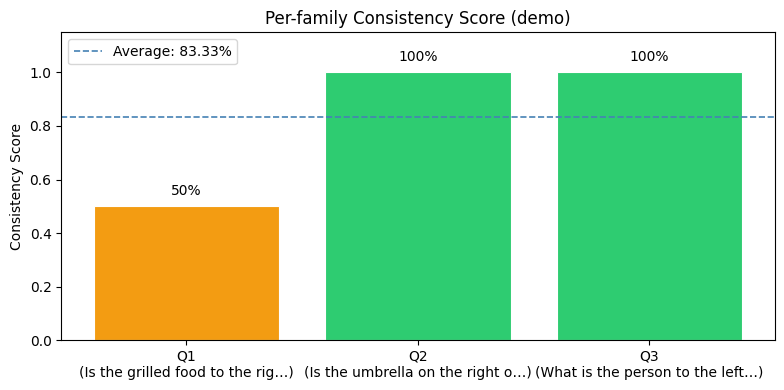

In [12]:
labels = [f"Q{i+1}\n({r['original_question'][:30]}…)" for i, r in enumerate(results)]
scores = [r['family_consistency_score'] for r in results]
colors = ['#2ecc71' if s == 1.0 else '#e74c3c' if s == 0.0 else '#f39c12' for s in scores]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, scores, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Consistency Score')
ax.set_title('Per-family Consistency Score (demo)')
ax.axhline(consistency, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Average: {consistency:.2%}')
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.03,
            f'{score:.0%}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()